# JaxFEM – Flachdecke 3D (HEX8)

Flachdecke, allseitig gelenkig gelagert (z=0, alle Translationen), gleichmäßige Flächenlast q auf Oberseite.

| Parameter | Wert |
|-----------|------|
| Länge Lx  | 5,5 m |
| Breite Ly | 4,0 m |
| Dicke h   | 0,20 m |
| Netz      | 32 × 16 × 4 (HEX8) |
| Knoten    | 4505  Elemente: 2048 |
| Material  | Beton C40/50, E=35 000 MPa, ν=0,2 |
| Last      | q = 5 kN/m² (Gleichlast auf Oberseite) |

Erzeugt von geobim.app FEM-Engineer, berechnet mit JaxFEM.

> ## JaxFEM API-Regeln (für Code-Generatoren / geobim.app)
>
> ### `jax_fem.logger_setup`
> - ❌ `logger_setup.setup()` — existiert **nicht**
> - ✅ `logger_setup.setup_logger('jax_fem')` — korrekte Funktion
>
> ### Koordinatenachsen (Flachdecke)
> - x = Längsrichtung (0 … Lx)
> - y = Querrichtung  (0 … Ly)
> - z = Plattendicke  (0 … h) → Durchbiegung `uz`, Biegespannungen `σ_xx`, `σ_yy`
> - Unterseite (Auflager): `z = 0`
> - Oberseite (Last):      `z = h`
>
> ### Mesh-Variante
> Bei kleinen Platten (grobe Netze) werden `points`/`cells` direkt als Arrays übergeben
> (statt `box_mesh`). Damit bleibt die Netzauflösung vollständig kontrollierbar.

In [46]:
import jax
import jax.numpy as np
import numpy as onp
import matplotlib.pyplot as plt
from jax_fem.generate_mesh import Mesh
from jax_fem.problem import Problem
from jax_fem.solver import solver
from jax_fem import logger_setup

logger_setup.setup_logger('jax_fem')
print('JAX-Version:', jax.__version__)

JAX-Version: 0.6.2


## 1. Geometrie & Netz

Netz via `box_mesh` (32×16×4 HEX8-Elemente) — deutlich feinere Auflösung für aussagekräftige Plots.

| Richtung | Länge | Elemente | Δ |
|----------|-------|----------|---|
| x        | 5,5 m | 32       | 0,172 m |
| y        | 4,0 m | 16       | 0,25 m |
| z        | 0,20 m| 4        | 0,05 m |

In [47]:
# ── Geometrieparameter ────────────────────────────────────
Lx = 5.5    # m – Länge  (x)
Ly = 4.0    # m – Breite (y)
Lz = 0.20   # m – Dicke  (z)
Nx = 32
Ny = 16
Nz = 4

from jax_fem.generate_mesh import box_mesh, get_meshio_cell_type

ele_type  = 'HEX8'
cell_type = get_meshio_cell_type(ele_type)

meshio_mesh = box_mesh(Nx=Nx, Ny=Ny, Nz=Nz,
                       domain_x=Lx, domain_y=Ly, domain_z=Lz)
mesh   = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])
points = meshio_mesh.points
cells  = meshio_mesh.cells_dict[cell_type]

print(f'Netz: {len(points)} Knoten, {len(cells)} Elemente')
print(f'Δx={Lx/Nx:.3f} m  Δy={Ly/Ny:.4f} m  Δz={Lz/Nz:.3f} m')

Netz: 2805 Knoten, 2048 Elemente
Δx=0.172 m  Δy=0.2500 m  Δz=0.050 m


## 2. Material & Last

Beton C40/50 (Einheiten: kN + m).  
Flächenlast q = 5 kN/m² auf der Oberseite (z = h), Richtung −z.

In [48]:
# ── Material (Beton C40/50, kN + m) ──────────────────────
E_MPa = 35000          # MPa
E  = E_MPa * 1_000.0   # kN/m²
nu = 0.2
mu    = E / (2.0 * (1.0 + nu))
lmbda = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))

# ── Last ───────────────────────────────────────────────────
q = 5   # kN/m²

print(f'E={E:.0f} kN/m²  nu={nu}  q={q} kN/m²')
print(f'Gesamtlast = {q * Lx * Ly:.1f} kN')

E=35000000 kN/m²  nu=0.2  q=5 kN/m²
Gesamtlast = 110.0 kN


## 3. Problem-Klasse (lineare Elastizität, 3D)

In [49]:
class LinearElasticity3D(Problem):
    def get_tensor_map(self):
        def stress(u_grad):
            epsilon = 0.5 * (u_grad + u_grad.T)
            sigma   = lmbda * np.trace(epsilon) * np.eye(self.dim) + 2.0 * mu * epsilon
            return sigma
        return stress

    def get_surface_maps(self):
        def load_top(u, x):
            return np.array([0.0, 0.0, -q])
        return [load_top]

## 4. Randbedingungen

| Auflager | Position | Typ | Gesperrt |
|----------|----------|-----|----------|
| Allseitig gelenkig | z=0 (Unterseite) | Gelenk | u_x, u_y, u_z |

Alle Freiheitsgrade an der Unterseite (z=0) fixiert — entspricht gelenkiger Lagerung der gesamten Unterseite.

In [50]:
# ── Lagerung ───────────────────────────────────────────────
# Gelenkig: alle Translationen an z=0 fixiert
def location_bottom(point):
    return np.isclose(point[2], 0.0, atol=1e-3)

def zero(point):
    return 0.0

dirichlet_bc_info = [[location_bottom] * 3,
                     [0, 1, 2],
                     [zero, zero, zero]]

# ── Neumann-Oberfläche ─────────────────────────────────────
z_max = float(onp.max(points[:, 2]))
def top_face(point):
    return np.isclose(point[2], z_max, atol=1e-3)

location_fns = [top_face]

print('Randbedingungen definiert.')
print(f'  z_max = {z_max} m  (Oberseite, Last-Fläche)')

Randbedingungen definiert.
  z_max = 0.2 m  (Oberseite, Last-Fläche)


## 5. Lösen

In [51]:
problem = LinearElasticity3D(
    mesh=mesh, vec=3, dim=3, ele_type='HEX8',
    dirichlet_bc_info=dirichlet_bc_info,
    location_fns=location_fns,
)
sol = solver(problem, solver_options={'umfpack_solver': {}})
print('Lösung berechnet. Shape:', sol[0].shape)

[04-20 12:26:35][DEBUG] jax_fem: Computing shape function values, gradients, etc.
[04-20 12:26:35][DEBUG] jax_fem: ele_type = HEX8, quad_points.shape = (num_quads, dim) = (8, 3)
[04-20 12:26:35][DEBUG] jax_fem: face_quad_points.shape = (num_faces, num_face_quads, dim) = (6, 4, 3)
[04-20 12:26:35][DEBUG] jax_fem: Done pre-computations, took 0.027451038360595703 [s]
[04-20 12:26:35][INFO] jax_fem: Solving a problem with 2048 cells, 2805x3 = 8415 dofs.
[04-20 12:26:35][INFO] jax_fem: Element type is HEX8, using 8 quad points per element.
[04-20 12:26:35][DEBUG] jax_fem: Calling the row elimination solver for imposing Dirichlet B.C.
[04-20 12:26:35][DEBUG] jax_fem: Start timing
[04-20 12:26:35][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[04-20 12:26:36][DEBUG] jax_fem: Function split_and_compute_cell took 0.0729 seconds
[04-20 12:26:36][DEBUG] jax_fem: Creating sparse matrix with scipy...
[04-20 12:26:36][DEBUG] jax_fem: Before, l_2 res = 4.747269096363822, relative l_2 r

Lösung berechnet. Shape: (2805, 3)


## 6. Ergebnisse

### 6.1 Maximale Durchbiegung w_max

FEM  w_max = 0.000 mm
Überhöhungsfaktor: ×50


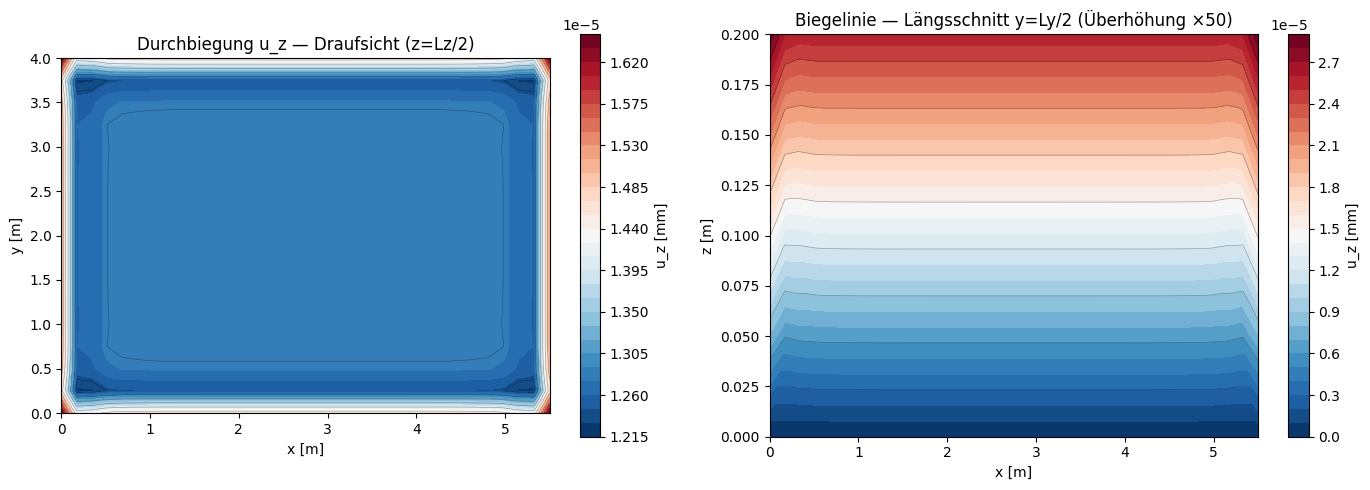

In [52]:
ux = onp.array(sol[0][:, 0])
uy = onp.array(sol[0][:, 1])
uz = onp.array(sol[0][:, 2])

w_fem = float(onp.min(uz))
print(f'FEM  w_max = {w_fem*1000:.3f} mm')

scale = min(0.1 * Lz / max(abs(w_fem), 1e-10), 50.0)
scale = max(round(scale, 0), 1.0)
print(f'Überhöhungsfaktor: ×{scale:.0f}')

# Mittelebene z ≈ Lz/2
mask_mid_z = onp.abs(points[:, 2] - Lz/2) < (Lz/Nz) * 0.8
mask_mid_y = onp.abs(points[:, 1] - Ly/2) < (Ly/Ny) * 0.8

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Draufsicht – Durchbiegung
xp = points[mask_mid_z, 0]
yp = points[mask_mid_z, 1]
cf0 = axes[0].tricontourf(xp, yp, uz[mask_mid_z]*1000, levels=30, cmap='RdBu_r')
axes[0].tricontour(xp, yp, uz[mask_mid_z]*1000, levels=10, colors='k', linewidths=0.4, alpha=0.4)
plt.colorbar(cf0, ax=axes[0], label='u_z [mm]')
axes[0].set_title('Durchbiegung u_z — Draufsicht (z=Lz/2)')
axes[0].set_xlabel('x [m]'); axes[0].set_ylabel('y [m]')
axes[0].set_aspect('equal')

# Längsschnitt y = Ly/2
xp2 = points[mask_mid_y, 0]
zp2 = points[mask_mid_y, 2] + scale * uz[mask_mid_y]
cf1 = axes[1].tricontourf(xp2, zp2, uz[mask_mid_y]*1000, levels=30, cmap='RdBu_r')
axes[1].tricontour(xp2, zp2, uz[mask_mid_y]*1000, levels=10, colors='k', linewidths=0.4, alpha=0.4)
plt.colorbar(cf1, ax=axes[1], label='u_z [mm]')
axes[1].set_title(f'Biegelinie — Längsschnitt y=Ly/2 (Überhöhung ×{scale:.0f})')
axes[1].set_xlabel('x [m]'); axes[1].set_ylabel('z [m]')

plt.tight_layout()
plt.show()

### 6.2 Spannungen (Gauss-Punkt-Extrapolation)

In [53]:
from scipy.spatial import cKDTree

def compute_stress_at_nodes_3d(problem, sol_array, points, cells):
    """Spannungen an Knoten via Gauss-Punkt-Extrapolation (HEX8, 2×2×2)."""
    gp = onp.array([-1/onp.sqrt(3), 1/onp.sqrt(3)])
    gp_triples = [(xi, eta, zeta) for xi in gp for eta in gp for zeta in gp]

    all_gp_coords = []
    all_sigma     = []

    for cell in cells:
        x_cell = points[cell]
        u_cell = sol_array[cell]

        for (xi, eta, zeta) in gp_triples:
            N = 0.125 * onp.array([
                (1-xi)*(1-eta)*(1-zeta), (1+xi)*(1-eta)*(1-zeta),
                (1+xi)*(1+eta)*(1-zeta), (1-xi)*(1+eta)*(1-zeta),
                (1-xi)*(1-eta)*(1+zeta), (1+xi)*(1-eta)*(1+zeta),
                (1+xi)*(1+eta)*(1+zeta), (1-xi)*(1+eta)*(1+zeta),
            ])
            dN_dxi = 0.125 * onp.array([
                [-(1-eta)*(1-zeta), -(1-xi)*(1-zeta), -(1-xi)*(1-eta)],
                [ (1-eta)*(1-zeta), -(1+xi)*(1-zeta), -(1+xi)*(1-eta)],
                [ (1+eta)*(1-zeta),  (1+xi)*(1-zeta), -(1+xi)*(1+eta)],
                [-(1+eta)*(1-zeta),  (1-xi)*(1-zeta), -(1-xi)*(1+eta)],
                [-(1-eta)*(1+zeta), -(1-xi)*(1+zeta),  (1-xi)*(1-eta)],
                [ (1-eta)*(1+zeta), -(1+xi)*(1+zeta),  (1+xi)*(1-eta)],
                [ (1+eta)*(1+zeta),  (1+xi)*(1+zeta),  (1+xi)*(1+eta)],
                [-(1+eta)*(1+zeta),  (1-xi)*(1+zeta),  (1-xi)*(1+eta)],
            ])

            J     = dN_dxi.T @ x_cell
            Jinv  = onp.linalg.inv(J)
            dN_dx = dN_dxi @ Jinv.T
            x_gp  = N @ x_cell
            grad_u = dN_dx.T @ u_cell

            eps = 0.5 * (grad_u + grad_u.T)
            sig = lmbda * onp.trace(eps) * onp.eye(3) + 2 * mu * eps

            all_gp_coords.append(x_gp)
            all_sigma.append(sig.flatten())

    all_gp_coords = onp.array(all_gp_coords)
    all_sigma     = onp.array(all_sigma)
    _, idx = cKDTree(all_gp_coords).query(points)
    return all_sigma[idx].reshape(-1, 3, 3)


sigma_nd = compute_stress_at_nodes_3d(problem, onp.array(sol[0]), points, cells)

sxx = sigma_nd[:, 0, 0]
syy = sigma_nd[:, 1, 1]
szz = sigma_nd[:, 2, 2]
sxz = sigma_nd[:, 0, 2]
syz = sigma_nd[:, 1, 2]
sxy = sigma_nd[:, 0, 1]
s_vm = onp.sqrt(0.5 * ((sxx-syy)**2 + (syy-szz)**2 + (szz-sxx)**2
                        + 6*(sxy**2 + syz**2 + sxz**2)))

print(f'σ_xx: min={sxx.min():.1f}  max={sxx.max():.1f}  kN/m²')
print(f'σ_yy: min={syy.min():.1f}  max={syy.max():.1f}  kN/m²')
print(f'τ_xz: min={sxz.min():.1f}  max={sxz.max():.1f}  kN/m²')
print(f'von-Mises max = {s_vm.max():.1f}  kN/m²')

σ_xx: min=0.1  max=1.4  kN/m²
σ_yy: min=0.2  max=1.4  kN/m²
τ_xz: min=-1.0  max=1.0  kN/m²
von-Mises max = 5.3  kN/m²


### 6.3 Spannungs-Plots (Draufsicht Mittelebene z = Lz/2)

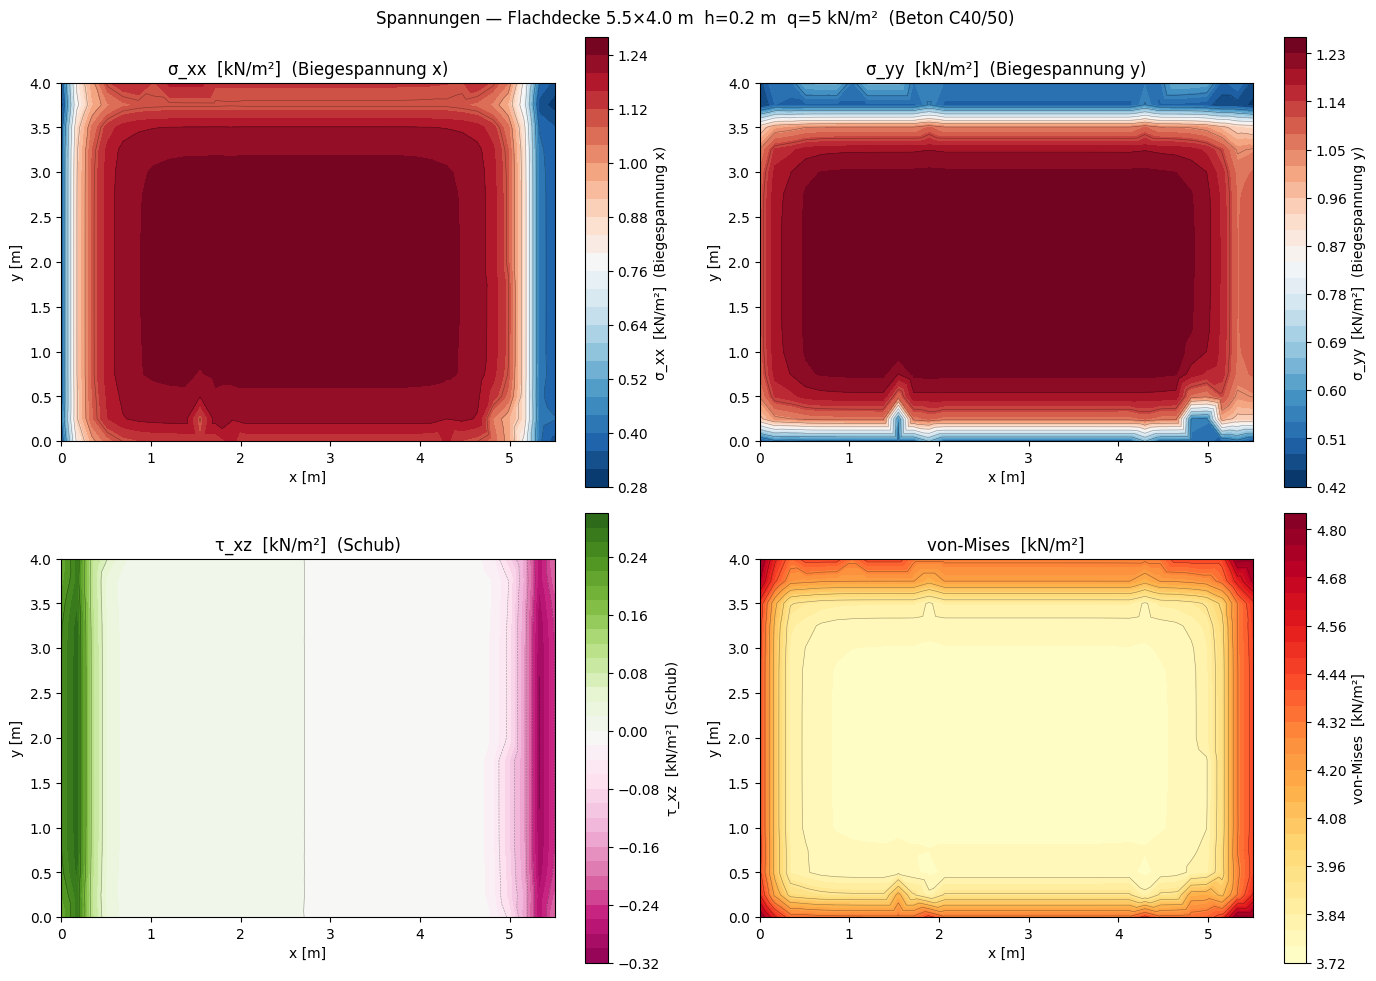

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

xp = points[mask_mid_z, 0]
yp = points[mask_mid_z, 1]

plots = [
    (sxx[mask_mid_z], 'σ_xx  [kN/m²]  (Biegespannung x)',  'RdBu_r'),
    (syy[mask_mid_z], 'σ_yy  [kN/m²]  (Biegespannung y)',  'RdBu_r'),
    (sxz[mask_mid_z], 'τ_xz  [kN/m²]  (Schub)',             'PiYG'),
    (s_vm[mask_mid_z], 'von-Mises  [kN/m²]',                'YlOrRd'),
]

for ax, (data, label, cmap) in zip(axes, plots):
    cf = ax.tricontourf(xp, yp, data, levels=30, cmap=cmap)
    ax.tricontour(xp, yp, data, levels=10, colors='k', linewidths=0.4, alpha=0.4)
    plt.colorbar(cf, ax=ax, label=label)
    ax.set_title(label)
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
    ax.set_aspect('equal')

plt.suptitle(f'Spannungen — Flachdecke {Lx}×{Ly} m  h={Lz} m  q={q} kN/m²  (Beton C40/50)', fontsize=12)
plt.tight_layout()
plt.show()